# Backtesting Trimestral 2025 — RNN-LSTM con Diferenciación Fraccionaria (FFD)

Análisis comparativo de **5 estrategias** de inversión sobre el universo de 23 activos durante 2025, con rebalanceo trimestral.

| Estrategia | Descripción |
|---|---|
| `model_top4_equal` | Top-4 por retorno predicho; pesos iguales |
| `model_top4_riskadjusted` | Top-4 por retorno predicho / volatilidad trailing |
| `model_top4_threshold` | Como Equal, pero solo activos con predicción > umbral; resto en cash |
| `model_top4_propweights` | Top-4 por retorno predicho; pesos proporcionales a la predicción (solo positivos) |
| `model_longshort` | Long top-4 / short bottom-4 por retorno predicho; pesos iguales (±25 %). Estrategia market-neutral |
| `bench_momentum` | Top-4 por retorno realizado en los últimos 90 días |
| `bench_momentum_input` | Top-4 por retorno realizado en los últimos N días (= ventana de entrada del modelo) |
| `bench_equalweight` | Buy & Hold con peso igual en los 23 activos |

**Modelo**: RNN-LSTM (input = 10 días, output = media de 90 días) **con diferenciación fraccionaria (FFD)**  
**Arquitectura ganadora**: 2 capas LSTM · 128 unidades · sin dropout · lr = 1e-4 · batch = 128  
**Entrenamiento**: datos hasta 31-dic-2024 | **Test out-of-sample**: 2025  
**FFD**: las series de retornos se transforman mediante diferenciación fraccionaria antes del entrenamiento y de la predicción, preservando la memoria a largo plazo al tiempo que se garantiza la estacionariedad.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches

# Añadimos project root, model/cnn y scripts al path
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parents[1]
SCRIPTS_DIR = NOTEBOOK_DIR.parent / "scripts"

for _p in [str(PROJECT_ROOT), str(PROJECT_ROOT / "model" / "cnn"), str(SCRIPTS_DIR)]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import backtest_quarterly_momentum as bt

bt.setup(model_type="lstm", input_window=10, output_window=90, ffd=True)

Modelo no encontrado. Entrenando con train_lstm_in10_out90_to2024.run() ...
Cargando datos desde returns_to2024.parquet ...
X_train: (10127, 10, 23)  X_val: (1125, 10, 23)  X_test: (1464, 10, 23)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 128)        │        77,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,375 (829.59 KB)

 Trainable params: 212,375 (829.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0829 - val_loss: 0.0376
Epoch 2/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0308 - val_loss: 0.0366
Epoch 3/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0271 - val_loss: 0.0346
Epoch 4/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0249 - val_loss: 0.0325
Epoch 5/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0231 - val_loss: 0.0311
Epoch 6/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0220 - val_loss: 0.0299
Epoch 7/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0212 - val_loss: 0.0296
Epoch 8/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0207 - val_loss: 0.0289
Epoch 9/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0203 - val_loss: 0.0283
Epoch 10/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0200 - val_loss: 0.0279
Epoch 11/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0198 - val_loss: 0.0274
Epoch 12/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0

## 1. Universo de activos

El universo está compuesto por **23 acciones del mercado estadounidense** (NYSE/NASDAQ).
Mostramos las estadísticas de retorno logarítmico diario durante el periodo de test (2025).

In [2]:
returns_2025 = bt.returns_full.loc["2025"]

print(f"Periodo out-of-sample : {returns_2025.index[0].date()} → {returns_2025.index[-1].date()}")
print(f"Días de trading       : {len(returns_2025)}")
print(f"\nActivos ({bt.n_assets}):")
print(bt.assets)

# Estadísticas de retorno diario en porcentaje
stats = (returns_2025.describe().T[["mean", "std", "min", "max"]] * 100).round(4)
stats.columns = ["Media diaria (%)", "Vol. diaria (%)", "Mínimo (%)", "Máximo (%)"]
display(stats.sort_values("Media diaria (%)", ascending=False))

Periodo out-of-sample : 2025-01-02 → 2025-12-31
Días de trading       : 250

Activos (23):
['AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD', 'GE', 'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM', 'MO', 'MRK', 'MSI', 'PG', 'XOM']


,Media diaria (%),Vol. diaria (%),Mínimo (%),Máximo (%)
Ticker,,,,
GE,0.2477,1.9178,-11.7617,10.0466
CAT,0.1888,2.0022,-9.0315,11.0061
JNJ,0.1554,1.2355,-7.8953,6.0090
IBM,0.1295,1.8824,-7.9301,12.1900
GD,0.1062,1.3355,-7.5513,6.5128
AEP,0.1030,1.2192,-4.3361,5.9034
MMM,0.0936,1.8608,-9.6305,8.4124
CNP,0.0852,1.0415,-3.4862,2.8763
BA,0.0817,2.3586,-11.0608,14.3010


## 2. Predicciones del LSTM-FFD en cada rebalanceo

En cada fecha de rebalanceo el modelo recibe los **últimos 10 días de la serie FFD(log\_precio)** de los 23 activos
y predice el **nivel medio de FFD(log\_precio) en los próximos 90 días**.

> **Nota sobre la escala**: la salida del modelo está en unidades de FFD(log\_precio) con d ≈ 0.2–0.4,
> que toma valores en el rango [0.1, 1.0]. Este valor **no es un retorno porcentual**:
> no tiene sentido multiplicarlo por 252 × 100 como si fuera un log-return diario.
>
> El gráfico muestra la **desviación de cada activo respecto a la media del universo**
> (señal cross-seccional), que es exactamente la información que usa la estrategia para
> seleccionar los 4 activos. Los activos en azul son los 4 seleccionados.

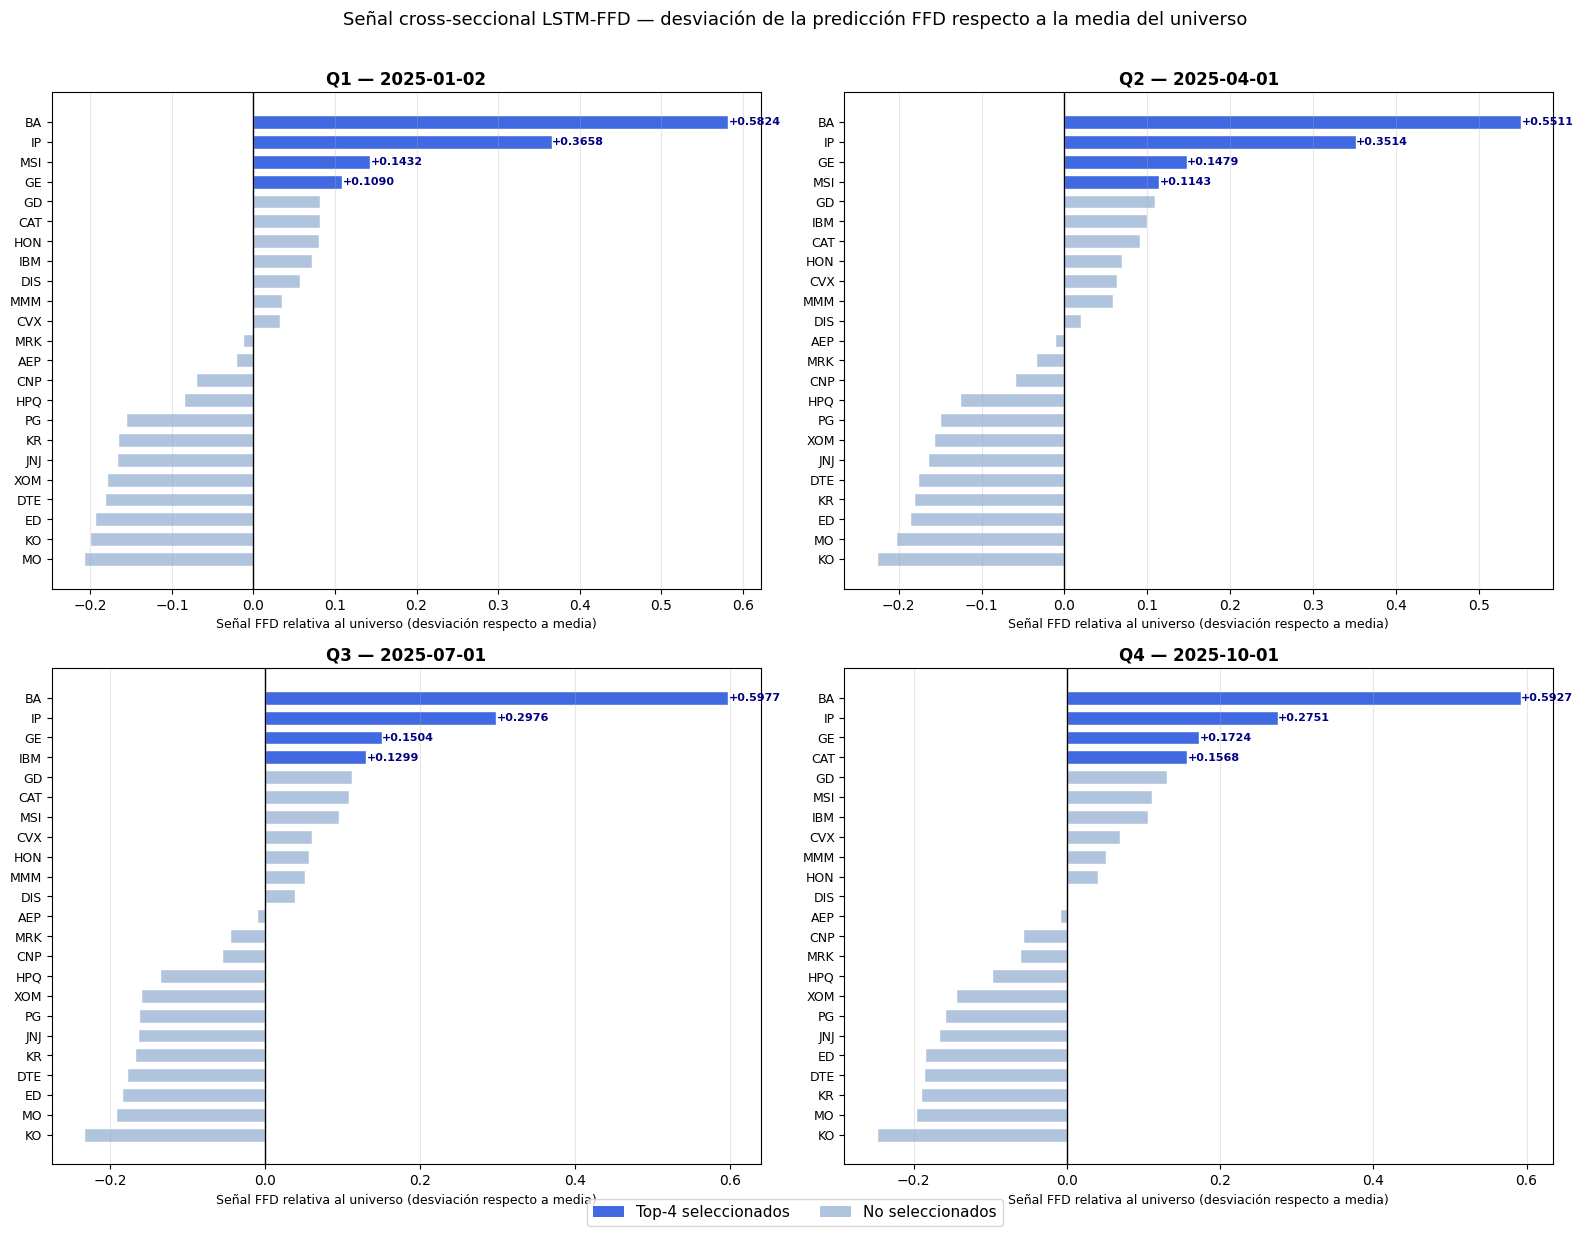

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for q_idx, (rb_date, ax) in enumerate(zip(bt.rebalance_dates, axes)):
    pred = bt.predict_at(rb_date)
    top4_idx = set(int(i) for i in np.argsort(pred)[::-1][:bt.N_TOP])
    order = list(np.argsort(pred))

    sorted_assets = [bt.assets[j] for j in order]
    # Señal cross-seccional: desviación de cada activo respecto al promedio del universo.
    # Es la cantidad relevante para el ranking (la estrategia usa argsort(pred), que es
    # invariante a traslaciones constantes), no el valor absoluto de FFD.
    pred_cs = pred - pred.mean()
    pred_display = [float(pred_cs[j]) for j in order]
    colors = ["royalblue" if j in top4_idx else "lightsteelblue" for j in order]

    bars = ax.barh(sorted_assets, pred_display, color=colors, edgecolor="white", height=0.7)
    ax.axvline(0, color="black", lw=1)
    ax.set_title(f"Q{q_idx + 1} — {rb_date.strftime('%Y-%m-%d')}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Señal FFD relativa al universo (desviación respecto a media)", fontsize=9)
    ax.grid(True, alpha=0.3, axis="x")
    ax.tick_params(axis="y", labelsize=9)

    for j_pos, (bar, val, j) in enumerate(zip(bars, pred_display, order)):
        if j in top4_idx:
            ax.text(
                val + 0.0005, bar.get_y() + bar.get_height() / 2,
                f"{val:+.4f}", va="center", fontsize=8, color="navy", fontweight="bold",
            )

legend_elems = [
    mpatches.Patch(facecolor="royalblue",      label="Top-4 seleccionados"),
    mpatches.Patch(facecolor="lightsteelblue", label="No seleccionados"),
]
fig.legend(handles=legend_elems, loc="lower center", ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.01))
fig.suptitle(
    "Señal cross-seccional LSTM-FFD — desviación de la predicción FFD respecto a la media del universo",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()

## 3. Ejecución del backtest

Ejecutamos el backtest trimestral para las 5 estrategias y mostramos qué activos selecciona cada una en cada periodo.

In [4]:
ret_df, holdings = bt.run_backtest()

LABELS = {
    "model_top4_equal":        "LSTM-FFD Equal",
    "model_top4_riskadjusted": "LSTM-FFD Risk-Adj.",
    "model_top4_threshold":    "LSTM-FFD Umbral",
    "model_top4_propweights":  "LSTM-FFD Prop. Pesos",
    "model_longshort":         "LSTM-FFD Long-Short",
    "bench_momentum":          "Momentum 90d",
    "bench_momentum_input":    f"Momentum {bt.INPUT_WINDOW}d",
    "bench_equalweight":       "Equal Weight",
}

# Tabla de selección de activos por trimestre
quarter_names = [f"Q{i+1} ({d.strftime('%b %Y')})" for i, d in enumerate(bt.rebalance_dates)]
rows = {}
for name, label in LABELS.items():
    row = []
    for q in range(len(bt.rebalance_dates)):
        if q < len(holdings[name]):
            h = holdings[name][q]
            if name == "bench_equalweight":
                row.append("todos (1/23)")
            elif name == "model_longshort":
                pred_q  = bt.predict_at(bt.rebalance_dates[q])
                order_q = np.argsort(pred_q)[::-1]
                long_a  = sorted([bt.assets[i] for i in order_q[:bt.N_TOP]])
                short_a = sorted([bt.assets[i] for i in order_q[-bt.N_TOP:]])
                row.append("L: " + ", ".join(long_a) + " | S: " + ", ".join(short_a))
            elif not h:
                row.append("cash")
            else:
                row.append(", ".join(sorted(h)))
        else:
            row.append("—")
    rows[label] = row

sel_df = pd.DataFrame(rows, index=quarter_names).T
display(sel_df)

Q1 (2025-01-02): pred top-4 = ['BA', 'IP', 'MSI', 'GE']
Q2 (2025-04-01): pred top-4 = ['BA', 'IP', 'GE', 'MSI']
Q3 (2025-07-01): pred top-4 = ['BA', 'IP', 'GE', 'IBM']
Q4 (2025-10-01): pred top-4 = ['BA', 'IP', 'GE', 'CAT']


,Q1 (Jan 2025),Q2 (Apr 2025),Q3 (Jul 2025),Q4 (Oct 2025)
LSTM-FFD Equal,"BA, GE, IP, MSI","BA, GE, IP, MSI","BA, GE, IBM, IP","BA, CAT, GE, IP"
LSTM-FFD Risk-Adj.,"BA, GD, IP, MSI","BA, GD, IP, MSI","BA, CNP, GD, MSI","BA, CAT, GD, MSI"
LSTM-FFD Umbral,"BA, GE, IP, MSI","BA, GE, IP, MSI","BA, GE, IBM, IP","BA, CAT, GE, IP"
LSTM-FFD Prop. Pesos,"BA, GE, IP, MSI","BA, GE, IP, MSI","BA, GE, IBM, IP","BA, CAT, GE, IP"
LSTM-FFD Long-Short,"L: BA, GE, IP, MSI | S: DTE, ED, KO, MO","L: BA, GE, IP, MSI | S: ED, KO, KR, MO","L: BA, GE, IBM, IP | S: DTE, ED, KO, MO","L: BA, CAT, GE, IP | S: DTE, KO, KR, MO"
Momentum 90d,"CNP, DIS, HON, KR","BA, CNP, IBM, KO","BA, GD, GE, MO","CAT, GD, GE, JNJ"
Momentum 10d,"AEP, BA, GE, JNJ","BA, CVX, MSI, XOM","CAT, GE, KR, MMM","AEP, CAT, DTE, IBM"
Equal Weight,todos (1/23),todos (1/23),todos (1/23),todos (1/23)


## 4. Retorno acumulado

Evolución del valor de la cartera (base 100) a lo largo de 2025.
Las líneas verticales punteadas marcan las fechas de rebalanceo trimestral.

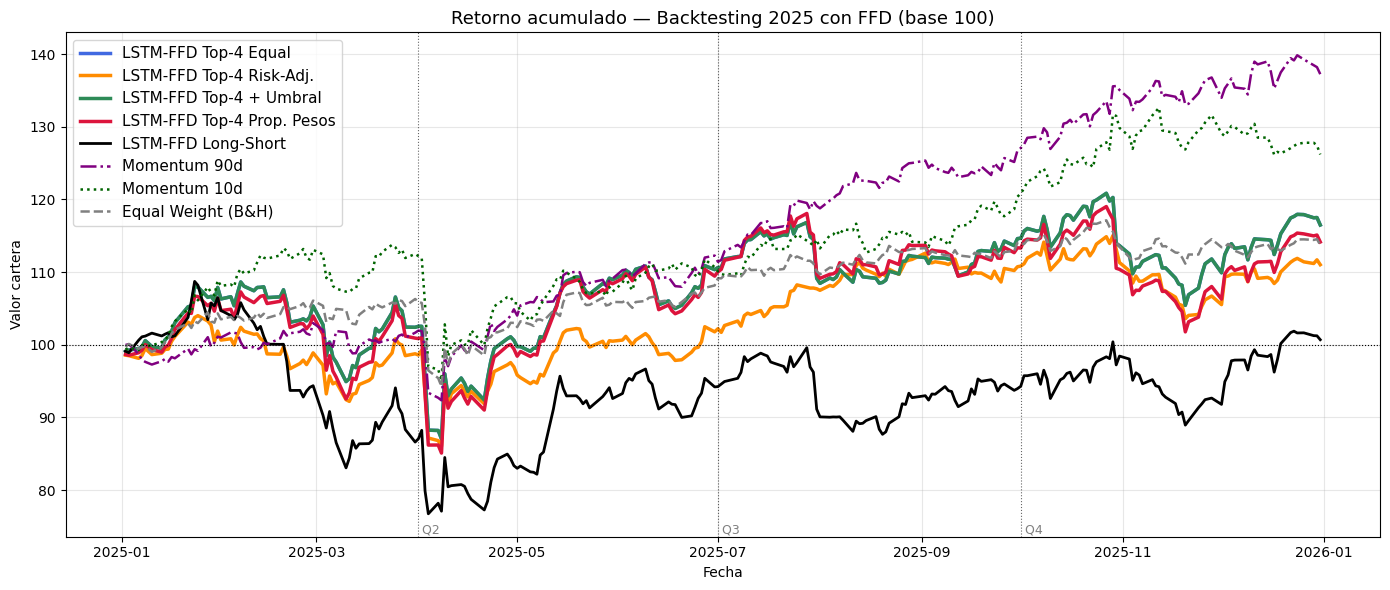

Retorno final (base 100):
  LSTM-FFD Top-4 Equal               : 116.49  (+16.49 %)
  LSTM-FFD Top-4 Risk-Adj.           : 111.02  (+11.02 %)
  LSTM-FFD Top-4 + Umbral            : 116.49  (+16.49 %)
  LSTM-FFD Top-4 Prop. Pesos         : 114.15  (+14.15 %)
  LSTM-FFD Long-Short                : 100.69  (+0.69 %)
  Momentum 90d                       : 137.25  (+37.25 %)
  Momentum 10d                       : 126.20  (+26.20 %)
  Equal Weight (B&H)                 : 113.73  (+13.73 %)


In [5]:
cum_value = ret_df.cumsum().apply(np.exp) * 100

STYLE = {
    "model_top4_equal":        dict(color="royalblue",  lw=2.5, ls="-",  label="LSTM-FFD Top-4 Equal"),
    "model_top4_riskadjusted": dict(color="darkorange", lw=2.5, ls="-",  label="LSTM-FFD Top-4 Risk-Adj."),
    "model_top4_threshold":    dict(color="seagreen",   lw=2.5, ls="-",  label="LSTM-FFD Top-4 + Umbral"),
    "model_top4_propweights":  dict(color="crimson",    lw=2.5, ls="-",  label="LSTM-FFD Top-4 Prop. Pesos"),
    "model_longshort":         dict(color="black",      lw=2.0, ls="-",  label="LSTM-FFD Long-Short"),
    "bench_momentum":          dict(color="purple",     lw=1.8, ls="-.", label="Momentum 90d"),
    "bench_momentum_input":    dict(color="darkgreen",  lw=1.8, ls=":",  label=f"Momentum {bt.INPUT_WINDOW}d"),
    "bench_equalweight":       dict(color="gray",       lw=1.8, ls="--", label="Equal Weight (B&H)"),
}

fig, ax = plt.subplots(figsize=(14, 6))
for name, style in STYLE.items():
    ax.plot(cum_value.index, cum_value[name], **style)

for i, rb in enumerate(bt.rebalance_dates[1:], start=2):
    ax.axvline(rb, color="black", lw=0.8, ls=":", alpha=0.6)
    ax.text(rb, ax.get_ylim()[0], f" Q{i}", fontsize=9, color="gray", va="bottom")

ax.axhline(100, color="black", lw=0.8, ls=":")
ax.set_title("Retorno acumulado — Backtesting 2025 con FFD (base 100)", fontsize=13)
ax.set_xlabel("Fecha")
ax.set_ylabel("Valor cartera")
ax.legend(fontsize=11, loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Retorno final (base 100):")
for name, style in STYLE.items():
    final = float(cum_value[name].iloc[-1])
    print(f"  {style['label']:35s}: {final:.2f}  ({final - 100:+.2f} %)")

## 5. Métricas de rendimiento

| Métrica | Descripción |
|---|---|
| **Retorno total (%)** | Ganancia acumulada en 2025 |
| **Sharpe ratio** | Retorno ajustado por riesgo (rf = 4 % anual) |
| **Max Drawdown (%)** | Caída máxima desde un máximo histórico |
| **Turnover medio** | Fracción de activos cambiados entre trimestres (0 = sin cambios, 1 = cartera completamente nueva) |

,Retorno (%),Sharpe,Max DD (%),Turnover
LSTM-FFD Equal,16.49,0.469,-19.88,0.333
LSTM-FFD Risk-Adj.,11.02,0.324,-17.29,0.333
LSTM-FFD Umbral,16.49,0.469,-19.88,0.333
LSTM-FFD Prop. Pesos,14.15,0.363,-20.68,0.333
LSTM-FFD Long-Short,0.69,-0.116,-29.43,0.833
Momentum 90d,37.25,1.726,-10.33,1.333
Momentum 10d,26.20,0.984,-16.39,1.667
Equal Weight,13.73,0.653,-11.33,0.000


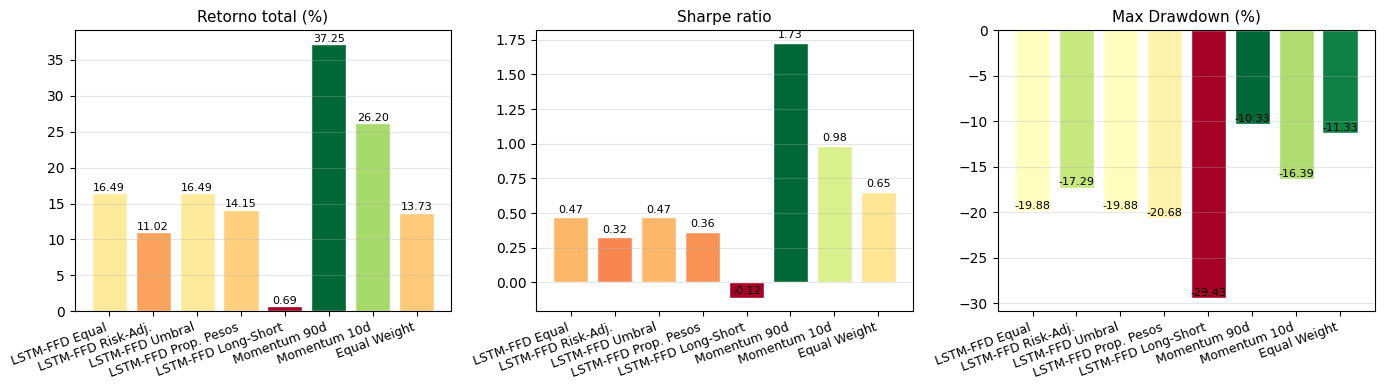

In [6]:
metrics_rows = [bt.compute_metrics(n, ret_df, holdings) for n in bt.STRATEGIES]
metrics = pd.DataFrame(metrics_rows).set_index("strategy")
metrics.index = [LABELS.get(n, n) for n in metrics.index]
metrics.columns = ["Retorno (%)", "Sharpe", "Max DD (%)", "Turnover"]

display(
    metrics.style
    .format({"Retorno (%)": "{:.2f}", "Sharpe": "{:.3f}", "Max DD (%)": "{:.2f}", "Turnover": "{:.3f}"})
    .background_gradient(subset=["Retorno (%)"], cmap="RdYlGn")
    .background_gradient(subset=["Sharpe"],      cmap="RdYlGn")
    .background_gradient(subset=["Max DD (%)"],  cmap="RdYlGn")
    .set_caption("Métricas de backtesting 2025 — LSTM con FFD")
)

# Gráfico de barras comparativo
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
cols   = ["Retorno (%)", "Sharpe", "Max DD (%)"]
cmaps  = ["RdYlGn", "RdYlGn", "RdYlGn"]
titles = ["Retorno total (%)", "Sharpe ratio", "Max Drawdown (%)"]

for ax, col, cmap_name, title in zip(axes, cols, cmaps, titles):
    vals   = metrics[col]
    cmap   = plt.get_cmap(cmap_name)
    norm   = plt.Normalize(vals.min(), vals.max())
    colors = [cmap(norm(v)) for v in vals]
    bars   = ax.bar(range(len(vals)), vals, color=colors, edgecolor="white")
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=20, ha="right", fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.3, axis="y")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f"{v:.2f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

### Interpretación de los resultados — Estrategia Long-Short

Los malos resultados de la estrategia Long-Short son **informativos, no un fallo del modelo**. Permiten extraer conclusiones importantes sobre la naturaleza predictiva del LSTM-FFD.

**¿Por qué las estrategias long-only funcionan pero la long-short no?**

Las estrategias long-only se benefician del **beta de mercado**: si el modelo predice retornos positivos para la mayoría de activos y se compran los 4 mejores, parte del retorno procede simplemente de que el mercado sube en conjunto. La estrategia long-short es **market-neutral**: elimina ese efecto y constituye una apuesta pura sobre la capacidad del modelo para *ordenar* activos entre sí (señal cross-sectional).

**Lo que el resultado revela**

El LSTM fue entrenado minimizando el MAE sobre retornos (transformados con FFD), no sobre el ranking relativo entre activos. Si los activos del bottom-4 no son sistemáticamente peores que los del top-4, la pata corta destruye valor activamente en lugar de añadirlo.

| Estrategia | Fuente principal de retorno |
|---|---|
| Long-only (Equal, Risk-Adj., Umbral, Prop.) | Beta de mercado + señal del modelo |
| **Long-Short** | **Solo señal cross-sectional del modelo** |

> **Posible mejora:** para que una estrategia long-short funcione, el modelo debería entrenarse con una función de pérdida orientada al ranking (p.ej. *pairwise ranking loss* o *ListNet*) en lugar de MAE, de modo que el gradiente de entrenamiento penalice directamente los errores de ordenación entre activos.

## 6. Análisis de drawdown

El drawdown mide la caída porcentual respecto al máximo histórico de la cartera.
Es el indicador de riesgo más visible para un inversor real.

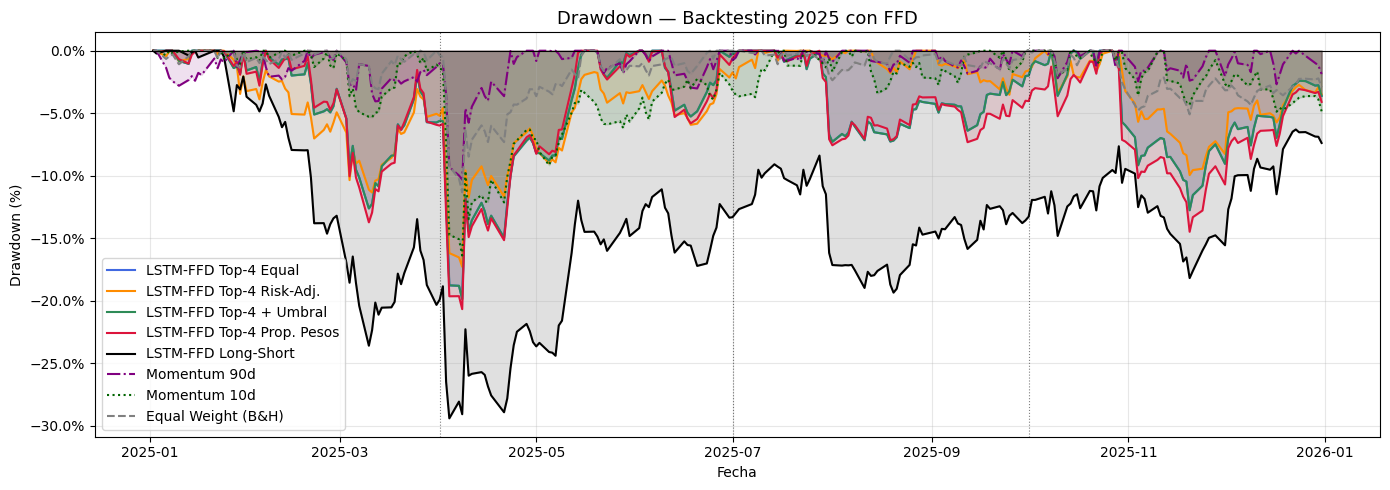

Max Drawdown por estrategia:
  LSTM-FFD Top-4 Equal               : -19.88 %
  LSTM-FFD Top-4 Risk-Adj.           : -17.29 %
  LSTM-FFD Top-4 + Umbral            : -19.88 %
  LSTM-FFD Top-4 Prop. Pesos         : -20.68 %
  LSTM-FFD Long-Short                : -29.43 %
  Momentum 90d                       : -10.33 %
  Momentum 10d                       : -16.39 %
  Equal Weight (B&H)                 : -11.33 %


In [7]:
fig, ax = plt.subplots(figsize=(14, 5))

for name, style in STYLE.items():
    cum = ret_df[name].cumsum().apply(np.exp)
    dd  = (cum - cum.cummax()) / cum.cummax() * 100
    ax.fill_between(dd.index, dd, 0, alpha=0.12, color=style["color"])
    ax.plot(dd.index, dd, lw=1.5, color=style["color"], ls=style["ls"], label=style["label"])

for rb in bt.rebalance_dates[1:]:
    ax.axvline(rb, color="black", lw=0.8, ls=":", alpha=0.5)

ax.axhline(0, color="black", lw=0.8)
ax.set_title("Drawdown — Backtesting 2025 con FFD", fontsize=13)
ax.set_xlabel("Fecha")
ax.set_ylabel("Drawdown (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=1))
ax.legend(fontsize=10, loc="lower left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Max Drawdown por estrategia:")
for name, style in STYLE.items():
    cum = ret_df[name].cumsum().apply(np.exp)
    dd  = (cum - cum.cummax()) / cum.cummax() * 100
    print(f"  {style['label']:35s}: {float(dd.min()):.2f} %")

## 7. Variabilidad de las predicciones entre trimestres

Con la diferenciación fraccionaria (FFD) las series de entrada son más estacionarias, lo que puede afectar tanto a la magnitud como a la variabilidad de las predicciones respecto al modelo sin FFD.

> **Nota sobre los benchmarks de momentum:**  
> Se incluyen dos variantes para situar el rendimiento del modelo en contexto:
> - **Momentum 90d** (`bench_momentum`): lookback de 90 días, igual al horizonte de inversión.
> - **Momentum Nd** (`bench_momentum_input`): lookback igual a la ventana de entrada del modelo. Garantiza que ambos parten de exactamente la misma información histórica.

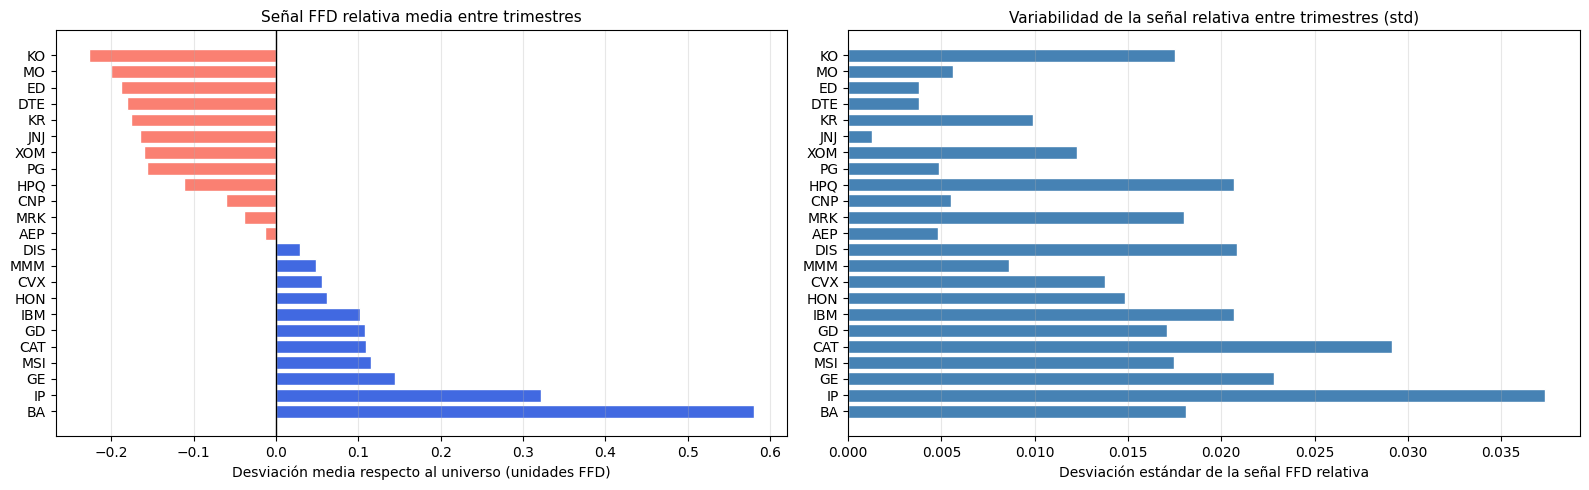

Activos con señal relativa > 0: 11 / 23
Spread medio de la señal (std entre activos): 0.187256

Ranking medio de señal relativa FFD:
  BA     media=+0.58099  std=0.01812
  IP     media=+0.32248  std=0.03736
  GE     media=+0.14491  std=0.02283
  MSI    media=+0.11583  std=0.01747
  CAT    media=+0.10901  std=0.02913
  GD     media=+0.10837  std=0.01710
  IBM    media=+0.10187  std=0.02070
  HON    media=+0.06134  std=0.01482
  CVX    media=+0.05640  std=0.01378
  MMM    media=+0.04871  std=0.00861
  DIS    media=+0.02918  std=0.02083
  AEP    media=-0.01305  std=0.00482
  MRK    media=-0.03858  std=0.01799
  CNP    media=-0.06062  std=0.00553
  HPQ    media=-0.11125  std=0.02069
  PG     media=-0.15705  std=0.00486
  XOM    media=-0.16019  std=0.01229
  JNJ    media=-0.16573  std=0.00126
  KR     media=-0.17631  std=0.00993
  DTE    media=-0.18118  std=0.00381
  ED     media=-0.18787  std=0.00382
  MO     media=-0.20001  std=0.00560
  KO     media=-0.22725  std=0.01751


In [8]:
# Predicciones en cada fecha de rebalanceo
preds_per_quarter = np.array([bt.predict_at(d) for d in bt.rebalance_dates])
# preds_per_quarter: (n_quarters, n_assets)

# Señal cross-seccional por trimestre: pred - media_universo
preds_cs = preds_per_quarter - preds_per_quarter.mean(axis=1, keepdims=True)

pred_std = preds_cs.std(axis=0)   # variabilidad de la señal relativa entre trimestres
pred_mean = preds_cs.mean(axis=0)  # señal media relativa (promedio entre trimestres)

order = np.argsort(pred_mean)[::-1]
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel izquierdo: señal media cross-seccional por activo
ax = axes[0]
vals = pred_mean[order]
colors = ["royalblue" if v > 0 else "salmon" for v in vals]
ax.barh([bt.assets[i] for i in order], vals, color=colors, edgecolor="white")
ax.axvline(0, color="black", lw=1)
ax.set_title("Señal FFD relativa media entre trimestres", fontsize=11)
ax.set_xlabel("Desviación media respecto al universo (unidades FFD)")
ax.grid(True, alpha=0.3, axis="x")

# Panel derecho: desviación estándar de la señal relativa entre trimestres
ax = axes[1]
std_vals = pred_std[order]
ax.barh([bt.assets[i] for i in order], std_vals, color="steelblue", edgecolor="white")
ax.set_title("Variabilidad de la señal relativa entre trimestres (std)", fontsize=11)
ax.set_xlabel("Desviación estándar de la señal FFD relativa")
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

print(f"Activos con señal relativa > 0: {(pred_mean > 1e-6).sum()} / {len(bt.assets)}")
print(f"Spread medio de la señal (std entre activos): {pred_mean.std():.6f}")
print(f"\nRanking medio de señal relativa FFD:")
for i in order:
    print(f"  {bt.assets[i]:5s}  media={pred_mean[i]:+.5f}  std={pred_std[i]:.5f}")

## 8. Rentabilidad neta de comisiones

Se aplica una comisión del **0,23 %** sobre el valor efectivo de cada operación.

**Modelo de costes:**
- En el primer trimestre (compra inicial) se paga comisión sobre el 100 % del capital invertido.
- En cada rebalanceo posterior se paga comisión únicamente por las posiciones que entran y salen:
  - Por cada activo que **sale**: se vende su parte proporcional de la cartera → comisión = 0,23 % × (V / N).
  - Por cada activo que **entra**: se compra al mismo importe → comisión = 0,23 % × (V / N).
- `bench_equalweight` mantiene los mismos 23 activos todos los trimestres → solo paga la comisión inicial.

In [9]:
COMMISSION_RATE = 0.0023   # 0,23 % sobre valor efectivo de cada operación

def compute_net_portfolio(strategy_name, ret_df, holdings, rebalance_dates):
    """Devuelve la serie de valor de cartera (base 100) neta de comisiones."""
    log_rets   = ret_df[strategy_name]
    hold_sets  = holdings[strategy_name]
    port_value = 100.0
    values     = []
    prev_set   = set()
    q_idx      = 0

    for date in log_rets.index:
        # ── Comisión al inicio de cada trimestre ──────────────────────────
        if q_idx < len(rebalance_dates) and date == rebalance_dates[q_idx]:
            curr_set = hold_sets[q_idx] if q_idx < len(hold_sets) else set()
            n_sell   = len(prev_set - curr_set)
            n_buy    = len(curr_set - prev_set)
            n_pos    = len(curr_set) or len(prev_set)
            if n_pos > 0:
                port_value -= (n_sell + n_buy) * (port_value / n_pos) * COMMISSION_RATE
            prev_set = curr_set
            q_idx   += 1

        # ── Retorno diario ────────────────────────────────────────────────
        port_value *= np.exp(log_rets[date])
        values.append(port_value)

    return pd.Series(values, index=log_rets.index)


# ── Calcular series netas ─────────────────────────────────────────────────────
net_portfolios = {
    name: compute_net_portfolio(name, ret_df, holdings, bt.rebalance_dates)
    for name in bt.STRATEGIES
}
net_df = pd.DataFrame(net_portfolios)

# ── Tabla comparativa bruto vs neto ──────────────────────────────────────────
gross_final = (ret_df.cumsum().apply(np.exp) * 100).iloc[-1]
net_final   = net_df.iloc[-1]
commission_drag = gross_final - net_final

def total_commission_pct(strategy_name):
    hold_sets = holdings[strategy_name]
    prev_set  = set()
    cost_pct  = 0.0
    for q_idx, curr_set in enumerate(hold_sets):
        n_sell = len(prev_set - curr_set)
        n_buy  = len(curr_set - prev_set)
        n_pos  = len(curr_set) or len(prev_set)
        if n_pos > 0:
            cost_pct += (n_sell + n_buy) / n_pos * COMMISSION_RATE * 100
        prev_set = curr_set
    return round(cost_pct, 4)

compare = pd.DataFrame({
    "Retorno bruto (%)":  (gross_final - 100).round(2),
    "Retorno neto (%)":   (net_final   - 100).round(2),
    "Coste comis. (p.p.)": commission_drag.round(3),
    "Coste comis. acum. (%)": {n: total_commission_pct(n) for n in bt.STRATEGIES},
    "Turnover medio": {n: bt.compute_metrics(n, ret_df, holdings)["avg_turnover"]
                       for n in bt.STRATEGIES},
})
compare.index = [LABELS.get(n, n) for n in compare.index]
display(
    compare.style
    .format({
        "Retorno bruto (%)":       "{:.2f}",
        "Retorno neto (%)":        "{:.2f}",
        "Coste comis. (p.p.)":     "{:.3f}",
        "Coste comis. acum. (%)": "{:.4f}",
        "Turnover medio":          "{:.3f}",
    })
    .background_gradient(subset=["Retorno neto (%)"],      cmap="RdYlGn")
    .background_gradient(subset=["Coste comis. (p.p.)"],   cmap="RdYlGn_r")
    .set_caption(f"Comisión aplicada: {COMMISSION_RATE*100:.2f} % por operación — LSTM con FFD")
)

,Retorno bruto (%),Retorno neto (%),Coste comis. (p.p.),Coste comis. acum. (%),Turnover medio
LSTM-FFD Equal,16.49,15.95,0.535,0.4600,0.333
LSTM-FFD Risk-Adj.,11.02,10.51,0.510,0.4600,0.333
LSTM-FFD Umbral,16.49,15.95,0.535,0.4600,0.333
LSTM-FFD Prop. Pesos,14.15,13.62,0.524,0.4600,0.333
LSTM-FFD Long-Short,0.69,0.17,0.520,0.5175,0.833
Momentum 90d,37.25,35.68,1.572,1.1500,1.333
Momentum 10d,26.20,24.47,1.733,1.3800,1.667
Equal Weight,13.73,13.47,0.262,0.2300,0.000


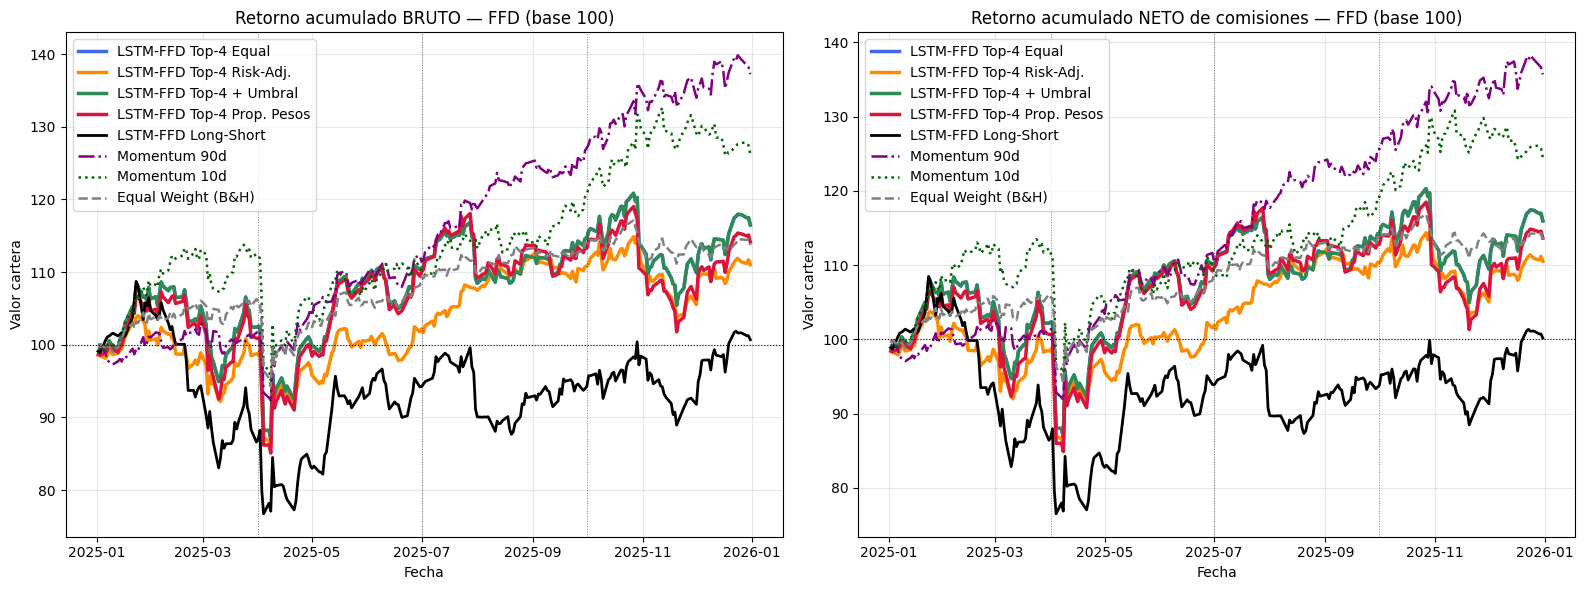

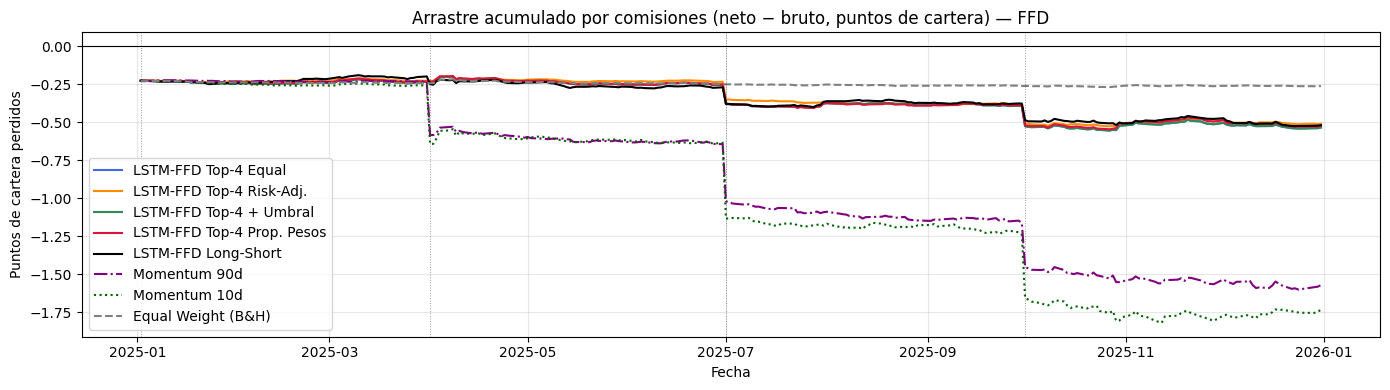


Ranking por retorno NETO (comisión = 0.23 %):
  Momentum 90d                  : +35.68 %   (bruto +37.25 %,  arrastre -1.572 p.)
  Momentum 10d                  : +24.47 %   (bruto +26.20 %,  arrastre -1.733 p.)
  LSTM-FFD Equal                : +15.95 %   (bruto +16.49 %,  arrastre -0.535 p.)
  LSTM-FFD Umbral               : +15.95 %   (bruto +16.49 %,  arrastre -0.535 p.)
  LSTM-FFD Prop. Pesos          : +13.62 %   (bruto +14.15 %,  arrastre -0.524 p.)
  Equal Weight                  : +13.47 %   (bruto +13.73 %,  arrastre -0.262 p.)
  LSTM-FFD Risk-Adj.            : +10.51 %   (bruto +11.02 %,  arrastre -0.510 p.)
  LSTM-FFD Long-Short           :  +0.17 %   (bruto  +0.69 %,  arrastre -0.520 p.)


In [10]:
# ── Gráfico: retorno acumulado bruto vs neto ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

gross_cum = (ret_df.cumsum().apply(np.exp) * 100)

for ax, values_dict, title in zip(
    axes,
    [gross_cum, net_df],
    ["Retorno acumulado BRUTO — FFD (base 100)", "Retorno acumulado NETO de comisiones — FFD (base 100)"],
):
    for name, style in STYLE.items():
        ax.plot(values_dict.index, values_dict[name], **style)
    for rb in bt.rebalance_dates[1:]:
        ax.axvline(rb, color="black", lw=0.7, ls=":", alpha=0.5)
    ax.axhline(100, color="black", lw=0.8, ls=":")
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Valor cartera")
    ax.legend(fontsize=10, loc="upper left")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Gráfico: diferencia neto - bruto (arrastre por comisiones) ────────────────
fig, ax = plt.subplots(figsize=(14, 4))

for name, style in STYLE.items():
    drag = net_df[name] - gross_cum[name]
    ax.plot(drag.index, drag, color=style["color"], lw=1.5,
            ls=style["ls"], label=style["label"])

for rb in bt.rebalance_dates:
    ax.axvline(rb, color="black", lw=0.7, ls=":", alpha=0.4)

ax.axhline(0, color="black", lw=0.8)
ax.set_title("Arrastre acumulado por comisiones (neto − bruto, puntos de cartera) — FFD", fontsize=12)
ax.set_xlabel("Fecha")
ax.set_ylabel("Puntos de cartera perdidos")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Ranking neto final ────────────────────────────────────────────────────────
print(f"\nRanking por retorno NETO (comisión = {COMMISSION_RATE*100:.2f} %):")
ranking = net_df.iloc[-1].sort_values(ascending=False)
for name, val in ranking.items():
    label   = LABELS.get(name, name)
    bruto   = float(gross_cum[name].iloc[-1])
    drag    = float(val - bruto)
    print(f"  {label:30s}: {val - 100:+6.2f} %   (bruto {bruto - 100:+6.2f} %,  arrastre {drag:+.3f} p.)")